In [2]:
import pandas as pd

In [35]:
df = pd.read_csv('Titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.drop(['PassengerId','Name','Ticket'],axis=1, inplace=True)

In [5]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


In [6]:
import importlib
import preprocessing_da

importlib.reload(preprocessing_da)
from preprocessing_da import drop_columns, get_data_summary

get_data_summary(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtype,int64,int64,object,float64,int64,int64,float64,object,object
n_unique,2,3,2,88,7,7,248,147,3


In [7]:
dtypes = df.dtypes
n_unuiqe = df.nunique()
pd.DataFrame({"Dtypes": dtypes, "N_unuiqe":n_unuiqe}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtypes,int64,int64,object,float64,int64,int64,float64,object,object
N_unuiqe,2,3,2,88,7,7,248,147,3


In [8]:
cols = ["Survived","Pclass","Sex","SibSp","Parch","Embarked"]
df[cols] = df[cols].astype("category")
pd.DataFrame(df.dtypes).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,category,category,category,float64,category,category,float64,object,category


In [9]:
null = df.isnull().sum()
ratio = (null/ df.shape[0])*100
pd.DataFrame({"null ": null, "ratio ":ratio}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
null,0.0,0.0,0.0,177.00000,0.0,0.0,0.0,687.000000,2.000000
ratio,0.0,0.0,0.0,19.86532,0.0,0.0,0.0,77.104377,0.224467


In [10]:
df = df.dropna(subset=['Embarked'])

In [11]:
df = df.drop("Cabin",axis=1)

In [12]:
median = df['Age'].median()
df['Age'] = df['Age'].fillna(median)

In [13]:
null = df.isnull().sum()
ratio = (null/ df.shape[0])*100
pd.DataFrame({"null ": null, "ratio ":ratio}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ratio,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
from config import CAT

print(CAT)

['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']


In [15]:
num_cols = df.select_dtypes(include=['number']).columns

In [16]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3- Q1
    Lower_Fence = Q1 - 1.5*IQR
    print(Lower_Fence)


2.5
-26.7605


In [17]:
df.describe()

,Age,Fare
count,889.000000,889.000000
mean,29.315152,32.096681
std,12.984932,49.697504
min,0.420000,0.000000
25%,22.000000,7.895800
50%,28.000000,14.454200
75%,35.000000,31.000000
max,80.000000,512.329200


In [18]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5* IQR
    upper_fence = Q3 +   1.5* IQR
    lower_outliers = df[ df[col] < lower_fence][col].values
    upper_outliers = df[ df[col] > upper_fence][col].values
    print(lower_outliers)

[2.   2.   0.83 2.   1.   1.   1.   2.   2.   0.92 2.   1.   1.   0.75
 2.   2.   2.   0.75 0.67 1.   0.42 2.   1.   0.83]
[]


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
plt.figure(figsize=(8,1))
for i , col in enumerate(num_cols):
    plt.subplot(1,2, i+1)
    sns.boxplot(df[col], orient="h")
    plt.title(f"{col}  boxplot")
plt.show()

<Figure size 800x100 with 2 Axes>

In [21]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5* IQR
    upper_fence = Q3 +   1.5* IQR
    # print(lower_fence)
    lower_outliers = df[   df[col] < lower_fence    ][col].values 
    upper_outliers = df[ df[col] > upper_fence][col].values 

    df[col] = df[col].replace(lower_outliers, lower_fence)
    df[col] = df[col].replace(upper_outliers, upper_fence)



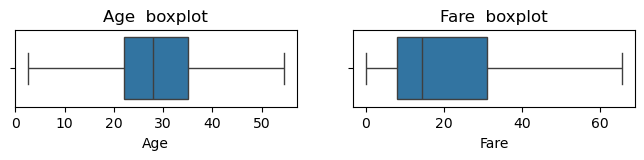

In [22]:
plt.figure(figsize=(8,1))
for i , col in enumerate(num_cols):
    plt.subplot(1,2, i+1)
    sns.boxplot(df[col], orient="h")
    plt.title(f"{col}  boxplot")
plt.show()

In [23]:
df.duplicated().sum()

129

In [24]:
df.drop_duplicates(inplace=True)

In [25]:
df.duplicated().sum()

0

In [26]:
def remove_duplicated(df, supset_cols = None, keep_strategy = "fisrt"):
    return df.drop_duplicates(supset_cols, keep = keep_strategy).reset_index(drop = True)

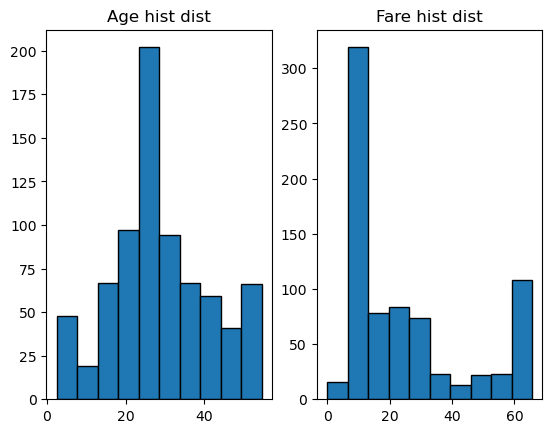

In [27]:
plt.Figure(figsize=(9,2))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i+1)
    plt.hist(df[col], edgecolor = "black")
    plt.title(f"{col} hist dist")

In [28]:
cat_cols = df.select_dtypes("category").columns
cat_cols

Index(['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked'], dtype='object')

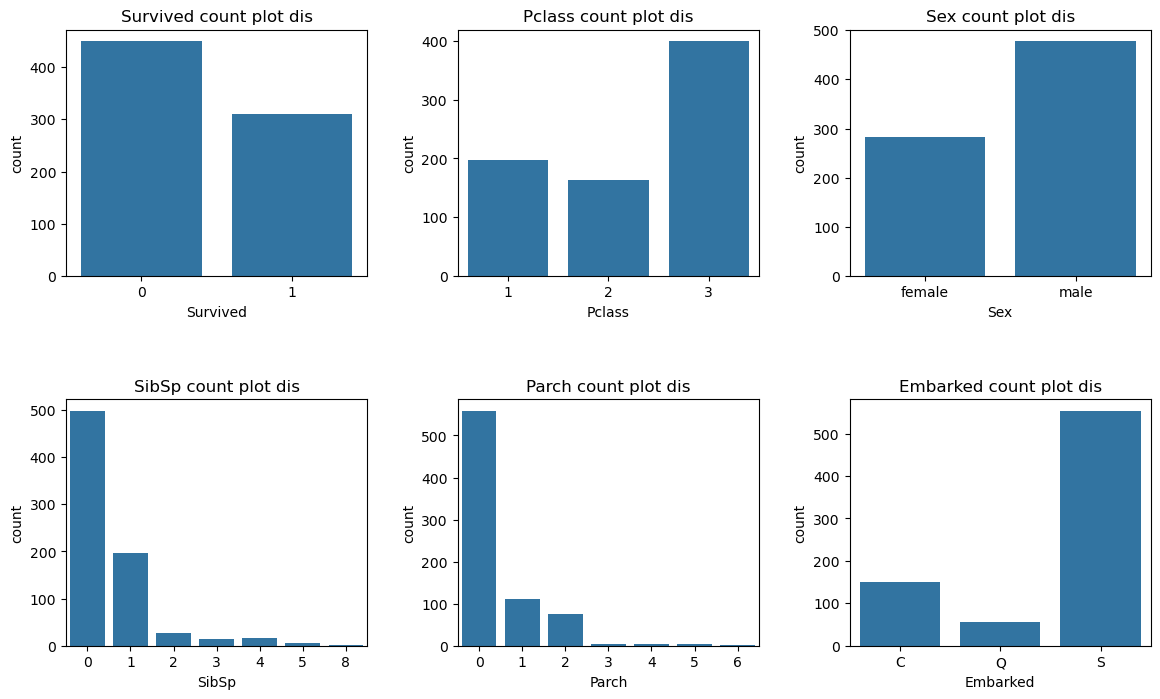

In [29]:
plt.figure(figsize=(14, 8))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i + 1)
    sns.countplot(x=col, data=df)
    plt.title(f"{col} count plot dis")
plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.show()

In [30]:
uniqe = df["Survived"].value_counts()
count = uniqe.values
category =uniqe.index

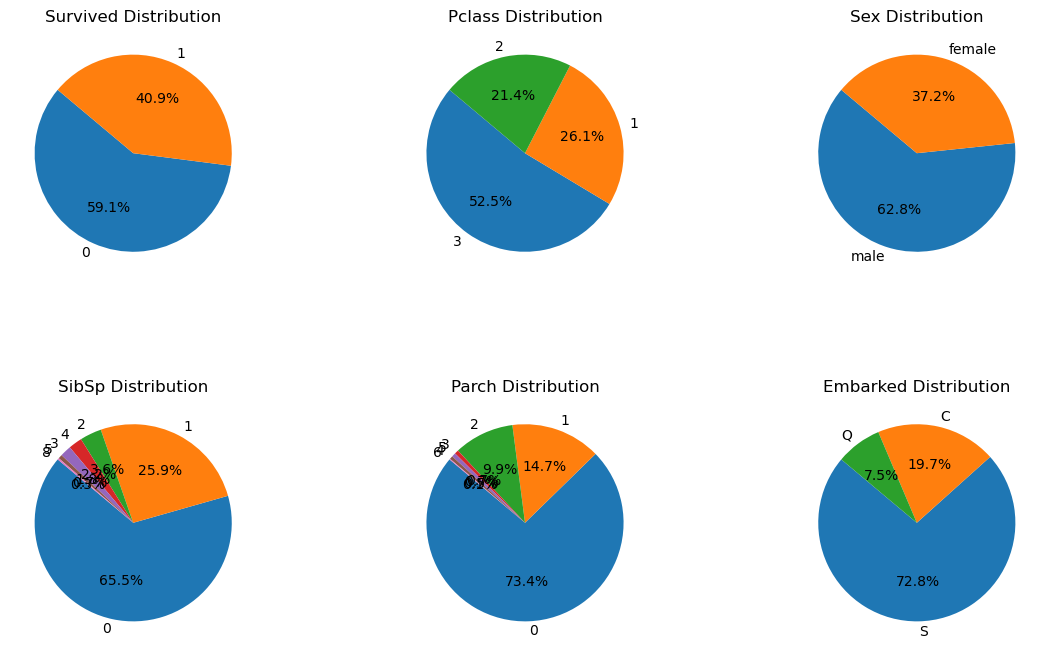

In [31]:
plt.figure(figsize=(14,8))

for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i + 1)
    
    uniq = df[col].value_counts()
    count = uniq.values
    category = uniq.index
    
    plt.pie(count, labels=category, startangle=140 ,autopct="%1.1f%%")
    plt.title(f"{col} Distribution")

plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.show()

In [32]:
import plotly.express as px
fig = px.pie(df , names= "Survived" ,color_discrete_sequence= px.colors.qualitative.Pastel , hole= 0.7)
fig.show()

Text(0, 0.5, "{'Fare'}")

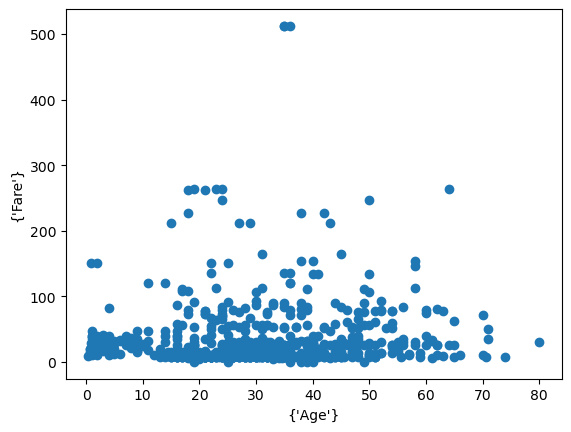

In [36]:
plt.Figure(figsize=(2,2))
plt.scatter(df["Age"],df["Fare"])
plt.xlabel({"Age"})
plt.ylabel({"Fare"})

In [34]:
fig = px.scatter(df[num_cols])
fig.show(render = "brwser")